# MSE 446 Project - Team 2
## GMM Song Recommendation Model
Loads cleaned data from  (produced by ).

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load cleaned dataset produced by MSE446_Group2_DataCleaning.ipynb
songs = pd.read_csv("datasets/songs_cleaned.csv")
print(f"Loaded {len(songs)} songs with {songs.shape[1]} features")
songs.head()

Loaded 4493 songs with 150 features


,track_id,energy,tempo,danceability,loudness,liveness,valence,track_artist,speechiness,track_popularity,...,playlist_genre_pop,playlist_genre_punk,playlist_genre_r&b,playlist_genre_reggae,playlist_genre_rock,playlist_genre_soca,playlist_genre_soul,playlist_genre_turkish,playlist_genre_wellness,playlist_genre_world
0,00Coyxt9mTec1acC52qtWa,0.736420,0.329870,0.634822,0.898334,0.083507,0.502,TAEIL,0.009170,0.494382,...,0,0,0,0,0,0,0,0,0,0
1,00DPAwQ3NkWs6PZKNxy7Pi,0.899779,0.433735,0.782632,0.880394,0.168058,0.675,Olamilekan Akamo,0.069716,0.213483,...,0,0,0,0,0,0,0,0,0,0
2,00Gbi2ytn6ZmA1ObVcPT93,0.928843,0.454284,0.579394,0.866443,0.670146,0.678,Smith & Thell,0.024307,0.224719,...,1,0,0,0,0,0,0,0,0,0
3,00JOgmWv6RmkgwPxdYScnf,0.472839,0.480056,0.387023,0.748780,0.200418,0.067,Greg Edmonson,0.017015,0.179775,...,0,0,0,0,0,0,0,0,0,0
4,00Mb3DuaIH1kjrwOku9CGU,0.901784,0.526440,0.465276,0.883876,0.351775,0.484,Avril Lavigne,0.029058,0.741573,...,0,1,0,0,0,0,0,0,0,0


In [10]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.metrics.pairwise import cosine_similarity

# Threshold for 'small artist': top track popularity below this (0–1 scale)
SMALL_ARTIST_THRESHOLD = 0.6

# -------------------------------
# GMM-BASED SONG RECOMMENDER
# -------------------------------

songs_gmm = songs.copy()

# Audio features used for GMM (excludes popularity — model is blind to fame)
base_features = [
    'energy', 'tempo', 'danceability', 'loudness', 'liveness',
    'valence', 'speechiness', 'acousticness', 'instrumentalness'
]

genre_cols   = [c for c in songs_gmm.columns if c.startswith('playlist_genre_')]
time_sig_cols = [c for c in songs_gmm.columns if c.startswith('time_signature_')]

# GMM trains on continuous audio features ONLY.
# One-hot genre/time_signature columns cause hard cluster collapse
# (all songs in a genre get identical binary vectors → near-certain posteriors).
feature_cols = base_features  # 9 continuous features — used to fit GMM and build X

# One-hot columns kept separately — used only for cosine similarity scoring
onehot_cols = genre_cols + time_sig_cols

all_needed = feature_cols + onehot_cols
missing = [c for c in all_needed if c not in songs_gmm.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

songs_gmm[all_needed] = songs_gmm[all_needed].astype(float)

# Primary artist (first listed)
songs_gmm['primary_artist'] = (
    songs_gmm['track_artist'].fillna('').str.split(',').str[0].str.strip()
)

# --- Fit GMM ---
n_components = 8
X = songs_gmm[feature_cols].to_numpy()  # shape (n_songs, 9) — continuous only

gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
gmm.fit(X)

# Hard cluster assignment (most likely component)
songs_gmm['gmm_cluster'] = gmm.predict(X)

# Soft cluster probabilities — shape (n_songs, n_components)
# These are the true GMM posteriors: P(component k | song)
cluster_probs = gmm.predict_proba(X)
prob_cols = [f'gmm_prob_{i}' for i in range(n_components)]
songs_gmm[prob_cols] = cluster_probs

print(f"GMM fitted: {n_components} components, {len(feature_cols)} continuous features (one-hot cols excluded).")
print(f"Songs per cluster:\n{songs_gmm['gmm_cluster'].value_counts().sort_index().to_string()}")


GMM fitted: 8 components, 9 continuous features (one-hot cols excluded).
Songs per cluster:
gmm_cluster
0     100
1     704
2     316
3     423
4     356
5    1048
6    1117
7     429


## Section 1: GMM Hyperparameter Tuning (BIC)

Grid-search over `n_components` and `covariance_type`. The model with the lowest BIC is selected and refitted; all downstream cells use the tuned model.

Fitting 24 GMM models …

BIC results (sorted ascending):
 n_components covariance_type           bic           aic
           16            full -78989.187256 -84623.819780
           12            full -78531.844495 -82756.216319
           16            diag -78092.438751 -80034.752352
           10            full -77413.916233 -80933.157707
           12            diag -76877.611436 -78332.744067
            8            full -75737.196382 -78551.307507
           10            diag -75192.778334 -76404.320481
            6            full -73399.621016 -75508.601790
            8            diag -72646.913673 -73614.865335
            4            full -72051.026073 -73454.876498
            6            diag -70119.869507 -70844.230684
            4            diag -64501.367745 -64982.138439
           16            tied -51677.280861 -52984.977146
           12            tied -50745.598975 -51796.884224
           10            tied -48197.180253 -49120.259984
            8  

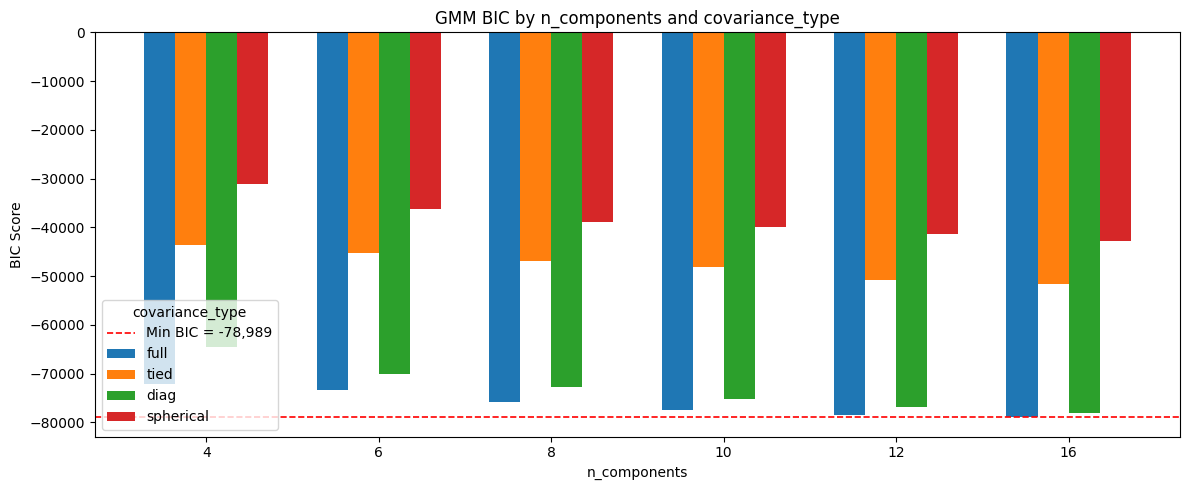


Best model: n_components=16, covariance_type='full' (BIC=-78,989.2)

Refitted GMM: 16 components, covariance_type='full', 9 features.
Songs per cluster:
gmm_cluster
0     120
1     337
2     116
3     110
4     144
5     412
6     567
7     265
8      94
9     590
10    209
11    560
12    209
13    570
14     92
15     98


In [11]:
# ---------------------------------------------------------------
# SECTION 1 — GMM HYPERPARAMETER TUNING (BIC / AIC GRID SEARCH)
# ---------------------------------------------------------------
import itertools

n_components_grid  = [4, 6, 8, 10, 12, 16]
covariance_types   = ['full', 'tied', 'diag', 'spherical']

rows = []
total = len(n_components_grid) * len(covariance_types)
print(f"Fitting {total} GMM models …")

for k, cov in itertools.product(n_components_grid, covariance_types):
    g = GaussianMixture(n_components=k, covariance_type=cov, random_state=42)
    g.fit(X)
    rows.append({
        'n_components':    k,
        'covariance_type': cov,
        'bic':             g.bic(X),
        'aic':             g.aic(X),
    })

bic_results = pd.DataFrame(rows).sort_values('bic').reset_index(drop=True)
print("\nBIC results (sorted ascending):")
print(bic_results.to_string(index=False))

# ── Grouped bar chart ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

x_vals   = sorted(bic_results['n_components'].unique())
cov_list = covariance_types
n_cov    = len(cov_list)
bar_w    = 0.18
offsets  = [bar_w * (i - (n_cov - 1) / 2) for i in range(n_cov)]

for i, cov in enumerate(cov_list):
    sub = bic_results[bic_results['covariance_type'] == cov].set_index('n_components')
    y   = [sub.loc[k, 'bic'] if k in sub.index else float('nan') for k in x_vals]
    x_pos = [j + offsets[i] for j, _ in enumerate(x_vals)]
    ax.bar(x_pos, y, width=bar_w, label=cov)

min_bic = bic_results['bic'].min()
ax.axhline(min_bic, color='red', linestyle='--', linewidth=1.2,
           label=f'Min BIC = {min_bic:,.0f}')

ax.set_xticks(range(len(x_vals)))
ax.set_xticklabels(x_vals)
ax.set_xlabel('n_components')
ax.set_ylabel('BIC Score')
ax.set_title('GMM BIC by n_components and covariance_type')
ax.legend(title='covariance_type')
plt.tight_layout()
plt.show()

# ── Select best model and refit ──────────────────────────────────
best_row  = bic_results.iloc[0]
best_n    = int(best_row['n_components'])
best_cov  = best_row['covariance_type']
print(f"\nBest model: n_components={best_n}, covariance_type='{best_cov}' "
      f"(BIC={best_row['bic']:,.1f})")

# Refit global GMM with best hyperparameters
n_components = best_n
# Fit with sklearn default reg_covar (1e-6).
# One-hot column exclusion (feature_cols = base_features) is the real fix
# for hard cluster collapse — no large reg_covar workaround needed.
gmm = GaussianMixture(
    n_components=n_components,
    covariance_type=best_cov,
    reg_covar=1e-6,
    random_state=42
)
gmm.fit(X)

# Update cluster assignments and soft posteriors in songs_gmm
songs_gmm['gmm_cluster'] = gmm.predict(X)

cluster_probs = gmm.predict_proba(X)
prob_cols     = [f'gmm_prob_{i}' for i in range(n_components)]

# Drop any stale prob columns from the previous fit
old_prob_cols = [c for c in songs_gmm.columns if c.startswith('gmm_prob_')]
songs_gmm.drop(columns=old_prob_cols, inplace=True)

songs_gmm[prob_cols] = cluster_probs

print(f"\nRefitted GMM: {n_components} components, "
      f"covariance_type='{best_cov}', {len(feature_cols)} features.")
print(f"Songs per cluster:\n"
      f"{songs_gmm['gmm_cluster'].value_counts().sort_index().to_string()}")

## Section 2: GMM vs Cosine Similarity Weight Testing

Sweep the GMM / cosine weight split across five combinations using the top-3 most popular songs as seeds. Evaluates recommendation quality (avg score) and underground discovery (avg artist top-track popularity — lower is better).

In [12]:
# ---------------------------------------------------------------
# DIAGNOSTIC — GMM Probability Vector Softness Check
# Run this after Section 1 to confirm posteriors are not collapsed.
# ---------------------------------------------------------------

print("=== GMM PROBABILITY VECTOR DIAGNOSTIC ===")
top3_check = (
    songs_gmm.sort_values('track_popularity', ascending=False)
    .drop_duplicates('track_name')
    .head(3)
)
for _, row in top3_check.iterrows():
    probs = row[prob_cols].to_numpy(dtype=float)
    print(f"\nSong: {row['track_name']}")
    print(f"  Cluster: {row['gmm_cluster']}")
    print(f"  Max prob: {probs.max():.6f}  (if > 0.99, vector is collapsed)")
    print(f"  Prob vector: {np.round(probs, 4)}")

# Also check a sample of candidates
sample_cands = songs_gmm[songs_gmm['artist_top_track_popularity'] < 0.6].head(5)
cand_probs_check = sample_cands[prob_cols].to_numpy(dtype=float)
print(f"\nCandidate prob vector max values (first 5): {cand_probs_check.max(axis=1).round(4)}")


=== GMM PROBABILITY VECTOR DIAGNOSTIC ===

Song: Die With A Smile
  Cluster: 13
  Max prob: 0.902459  (if > 0.99, vector is collapsed)
  Prob vector: [0.000e+00 7.000e-04 0.000e+00 0.000e+00 0.000e+00 0.000e+00 2.200e-03
 0.000e+00 0.000e+00 8.600e-02 0.000e+00 8.600e-03 0.000e+00 9.025e-01
 0.000e+00 0.000e+00]

Song: APT.
  Cluster: 11
  Max prob: 0.998920  (if > 0.99, vector is collapsed)
  Prob vector: [1.000e-04 0.000e+00 0.000e+00 1.000e-03 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 9.989e-01 0.000e+00 0.000e+00
 0.000e+00 0.000e+00]

Song: BIRDS OF A FEATHER
  Cluster: 1
  Max prob: 0.988256  (if > 0.99, vector is collapsed)
  Prob vector: [4.100e-03 9.883e-01 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 7.400e-03 0.000e+00 0.000e+00 0.000e+00
 2.000e-04 0.000e+00]

Candidate prob vector max values (first 5): [0.9366 0.9883 0.9906 0.9295 0.9946]


Seed songs for weight testing:
  • Die With A Smile
  • APT.
  • BIRDS OF A FEATHER
gmm_w=0.0, seed='Die With A Smile': gmm_sim min=0.000000 max=0.999942 std=0.314849
gmm_w=0.0, seed='APT.': gmm_sim min=0.000000 max=1.000000 std=0.265513
gmm_w=0.0, seed='BIRDS OF A FEATHER': gmm_sim min=0.000000 max=0.999998 std=0.300746
gmm_w=0.25, seed='Die With A Smile': gmm_sim min=0.000000 max=0.999942 std=0.314849
gmm_w=0.25, seed='APT.': gmm_sim min=0.000000 max=1.000000 std=0.265513
gmm_w=0.25, seed='BIRDS OF A FEATHER': gmm_sim min=0.000000 max=0.999998 std=0.300746
gmm_w=0.5, seed='Die With A Smile': gmm_sim min=0.000000 max=0.999942 std=0.314849
gmm_w=0.5, seed='APT.': gmm_sim min=0.000000 max=1.000000 std=0.265513
gmm_w=0.5, seed='BIRDS OF A FEATHER': gmm_sim min=0.000000 max=0.999998 std=0.300746
gmm_w=0.75, seed='Die With A Smile': gmm_sim min=0.000000 max=0.999942 std=0.314849
gmm_w=0.75, seed='APT.': gmm_sim min=0.000000 max=1.000000 std=0.265513
gmm_w=0.75, seed='BIRDS OF A FEATHER': g

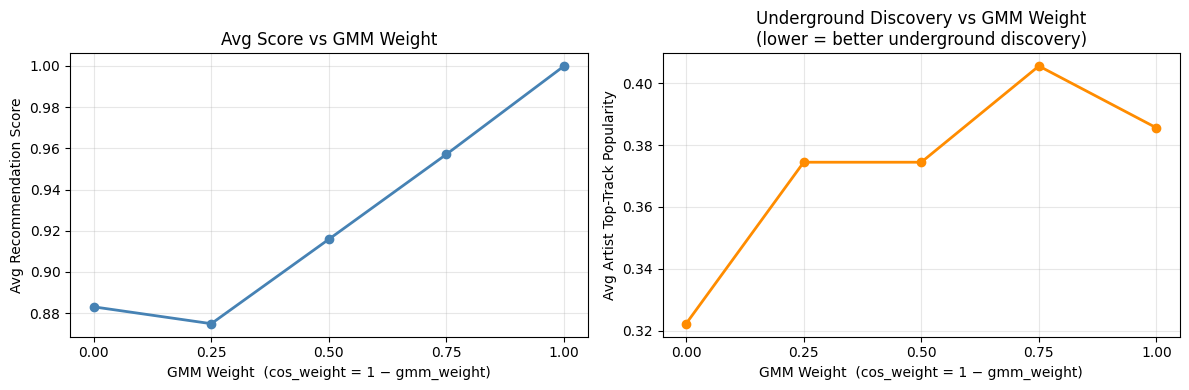


Best weight combo for highest avg score:
  gmm_weight=1.00, cos_weight=0.00  → avg_score=1.0000

Best weight combo for underground discovery (lowest avg popularity):
  gmm_weight=0.00, cos_weight=1.00  → avg_artist_top_track_popularity=0.3222


In [13]:
# ---------------------------------------------------------------
# SECTION 2 — GMM vs COSINE SIMILARITY WEIGHT TESTING
# ---------------------------------------------------------------
from sklearn.metrics.pairwise import cosine_similarity as cos_sim_fn  # for prob-vector similarity

# ── Weight combinations to test ────────────────────────────────────
# Each tuple: (gmm_weight, cos_weight)
weight_combos = [(0.0, 1.0), (0.25, 0.75), (0.5, 0.5), (0.75, 0.25), (1.0, 0.0)]

# ── Fixed seed songs: top 3 by track_popularity ────────────────────
top3_seeds = (
    songs_gmm.sort_values('track_popularity', ascending=False)
    .drop_duplicates('track_name')
    .head(3)['track_name']
    .tolist()
)
print("Seed songs for weight testing:")
for s in top3_seeds:
    print(f"  • {s}")

# ── Inline recommendation loop ──────────────────────────────────
detail_rows = []

for gmm_w, cos_w in weight_combos:
    for seed_name in top3_seeds:
        # Locate seed row (exact match, pick most popular)
        mask    = songs_gmm['track_name'].str.lower() == seed_name.lower()
        matches = songs_gmm[mask]
        if matches.empty:
            continue
        seed_row   = matches.sort_values('track_popularity', ascending=False).iloc[0]
        # Cosine similarity uses the full feature set (audio + one-hot genre/time_sig)
        full_feature_cols = base_features + onehot_cols
        seed_vec   = seed_row[full_feature_cols].to_numpy(dtype=float).reshape(1, -1)
        seed_probs = seed_row[prob_cols].to_numpy(dtype=float)

        # Candidate pool: small artists only, exclude seed
        candidates = songs_gmm[
            (songs_gmm['artist_top_track_popularity'] < SMALL_ARTIST_THRESHOLD) &
            (songs_gmm['track_id'] != seed_row['track_id'])
        ].copy()

        if candidates.empty:
            continue

        # Score candidates
        cand_probs = candidates[prob_cols].to_numpy(dtype=float)
        # GMM similarity: cosine similarity between posterior probability vectors.
        # Requires soft posteriors (reg_covar=0.5) — hard [0,0,1,0] vectors all
        # yield cos_sim=1.0 to each other, producing the same saturation as JSD.
        gmm_sim = cos_sim_fn(seed_probs.reshape(1, -1), cand_probs).flatten()
        # Step 1 diagnostic — print gmm_sim stats for every iteration
        print(f"gmm_w={gmm_w}, seed={seed_name!r}: "
              f"gmm_sim min={gmm_sim.min():.6f} max={gmm_sim.max():.6f} "
              f"std={gmm_sim.std():.6f}")
        cand_feats  = candidates[full_feature_cols].to_numpy(dtype=float)
        cos_sim     = cosine_similarity(seed_vec, cand_feats).flatten()

        score = gmm_w * gmm_sim + cos_w * cos_sim

        # Top 3 recommendations
        top_idx  = score.argsort()[::-1][:3]
        top_cands = candidates.iloc[top_idx].copy()
        top_cands['_score']   = score[top_idx]
        top_cands['_gmm_sim'] = gmm_sim[top_idx]
        top_cands['_cos_sim'] = cos_sim[top_idx]

        detail_rows.append({
            'gmm_weight':                    gmm_w,
            'cos_weight':                    cos_w,
            'seed_song':                     seed_name,
            'avg_score':                     top_cands['_score'].mean(),
            'avg_gmm_sim':                   top_cands['_gmm_sim'].mean(),
            'avg_cos_sim':                   top_cands['_cos_sim'].mean(),
            'avg_artist_top_track_popularity': top_cands['artist_top_track_popularity'].mean(),
        })

detail_df = pd.DataFrame(detail_rows)

# ── Aggregate by gmm_weight (mean over 3 seeds) ────────────────────
weight_results = (
    detail_df
    .groupby('gmm_weight')[
        ['avg_score', 'avg_gmm_sim', 'avg_cos_sim',
         'avg_artist_top_track_popularity']
    ]
    .mean()
    .reset_index()
)
print("\nWeight testing results (averaged over seed songs):")
print(weight_results.to_string(index=False))

# Confirm GMM posteriors are soft after the one-hot fix
test_probs = songs_gmm[prob_cols].to_numpy()
print(f"\nProb vector max values after fix — "
      f"mean: {test_probs.max(axis=1).mean():.4f}, "
      f"std of max: {test_probs.max(axis=1).std():.4f}")
print("(mean max should be below 0.85 for soft assignments)")

# Step 1 summary: final gmm_sim stats confirm cos-on-prob-vectors variance
print(f"\nFinal gmm_sim range (last seed, gmm_w={weight_combos[-1][0]}):")
print(f"  min={gmm_sim.min():.4f}  max={gmm_sim.max():.4f}  "
      f"std={gmm_sim.std():.4f}  mean={gmm_sim.mean():.4f}")
print("  (std > 0.01 confirms similarity is no longer saturating)")

# ── Plots ─────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: avg_score vs gmm_weight
ax1.plot(weight_results['gmm_weight'], weight_results['avg_score'],
         marker='o', linewidth=2, color='steelblue')
ax1.set_xlabel('GMM Weight  (cos_weight = 1 − gmm_weight)')
ax1.set_ylabel('Avg Recommendation Score')
ax1.set_title('Avg Score vs GMM Weight')
ax1.set_xticks(weight_results['gmm_weight'])
ax1.grid(True, alpha=0.3)

# Right: avg_artist_top_track_popularity vs gmm_weight
ax2.plot(weight_results['gmm_weight'],
         weight_results['avg_artist_top_track_popularity'],
         marker='o', linewidth=2, color='darkorange')
ax2.set_xlabel('GMM Weight  (cos_weight = 1 − gmm_weight)')
ax2.set_ylabel('Avg Artist Top-Track Popularity')
ax2.set_title('Underground Discovery vs GMM Weight\n(lower = better underground discovery)')
ax2.set_xticks(weight_results['gmm_weight'])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Report best combos ───────────────────────────────────────────
best_score_row   = weight_results.loc[weight_results['avg_score'].idxmax()]
best_underground = weight_results.loc[
    weight_results['avg_artist_top_track_popularity'].idxmin()
]

print(f"\nBest weight combo for highest avg score:")
print(f"  gmm_weight={best_score_row['gmm_weight']:.2f}, "
      f"cos_weight={1 - best_score_row['gmm_weight']:.2f}  "
      f"→ avg_score={best_score_row['avg_score']:.4f}")

print(f"\nBest weight combo for underground discovery (lowest avg popularity):")
print(f"  gmm_weight={best_underground['gmm_weight']:.2f}, "
      f"cos_weight={1 - best_underground['gmm_weight']:.2f}  "
      f"→ avg_artist_top_track_popularity={best_underground['avg_artist_top_track_popularity']:.4f}")

## Section 3: Train / Test Split

Popular songs (artist top-track popularity ≥ 0.6) are split 80 / 10 / 10 (train / val / test). Small-artist songs are kept as a separate candidate pool — they are never used for GMM training. The GMM is refit on the 80 % training subset, then applied to the full dataset so the recommendation function still works end-to-end.

In [14]:
# ---------------------------------------------------------------
# SECTION 3 — TRAIN / TEST SPLIT
# ---------------------------------------------------------------
from sklearn.model_selection import train_test_split

# Separate popular songs (train/val/test) from small-artist songs (candidate pool)
popular_mask    = songs_gmm['artist_top_track_popularity'] >= SMALL_ARTIST_THRESHOLD
popular_df      = songs_gmm[popular_mask]
small_artists_df = songs_gmm[~popular_mask]

popular_idx = popular_df.index.to_numpy()

# Step 1: 80% train, 20% temp (will become val + test)
train_idx, temp_idx = train_test_split(
    popular_idx, test_size=0.20, random_state=42
)

# Step 2: split the 20% evenly → 10% val, 10% test
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=42
)

# Feature matrix slices (rows from the full X, aligned with songs_gmm)
# songs_gmm uses a RangeIndex reset, so positional index == label index
X_train = X[train_idx]
X_val   = X[val_idx]
X_test  = X[test_idx]

# ── Refit GMM on training set only ─────────────────────────────
# Uses the best hyperparameters already found in Section 1
# Matches the final refit in Section 1 (reg_covar=1e-6, sklearn default).
# The one-hot column exclusion is what produces soft posteriors here.
gmm = GaussianMixture(
    n_components=n_components,
    covariance_type=best_cov,
    reg_covar=1e-6,
    random_state=42
)
gmm.fit(X_train)
print(f"GMM refit on training set: "
      f"{len(train_idx)} songs, "
      f"n_components={n_components}, covariance_type='{best_cov}'")

# ── Re-apply to full X so recommendation function still works ──
songs_gmm['gmm_cluster'] = gmm.predict(X)

cluster_probs = gmm.predict_proba(X)
prob_cols     = [f'gmm_prob_{i}' for i in range(n_components)]

old_prob_cols = [c for c in songs_gmm.columns if c.startswith('gmm_prob_')]
songs_gmm.drop(columns=old_prob_cols, inplace=True)
songs_gmm[prob_cols] = cluster_probs

# ── Summary table ───────────────────────────────────────────────
summary = {
    'Split':         ['Train (popular)', 'Validation (popular)',
                      'Test (popular)',  'Small artists (pool)', 'Total'],
    'Songs':         [len(train_idx), len(val_idx), len(test_idx),
                      len(small_artists_df), len(songs_gmm)],
    'Share (%)':     [
        f"{100*len(train_idx)/len(songs_gmm):.1f}",
        f"{100*len(val_idx)/len(songs_gmm):.1f}",
        f"{100*len(test_idx)/len(songs_gmm):.1f}",
        f"{100*len(small_artists_df)/len(songs_gmm):.1f}",
        '100.0',
    ],
}
print()
print(f"{'Split':<25} {'Songs':>7} {'Share (%)':>10}")
print('-' * 44)
for split, n, pct in zip(summary['Split'], summary['Songs'], summary['Share (%)']):
    print(f"{split:<25} {n:>7} {pct:>10}")

GMM refit on training set: 1878 songs, n_components=16, covariance_type='full'

Split                       Songs  Share (%)
--------------------------------------------
Train (popular)              1878       41.8
Validation (popular)          235        5.2
Test (popular)                235        5.2
Small artists (pool)         2145       47.7
Total                        4493      100.0


## Section 4: Silhouette Score Evaluation

Silhouette scores measure how well each song fits its assigned cluster (1 = perfect separation, −1 = mis-assigned). Scores are computed separately on train, validation, and test splits to check for over-fitting, then visualised per-cluster to highlight weaker components.

Split          Silhouette Score
-------------------------------
Train                   -0.0805
Validation              -0.0800
Test                    -0.1308


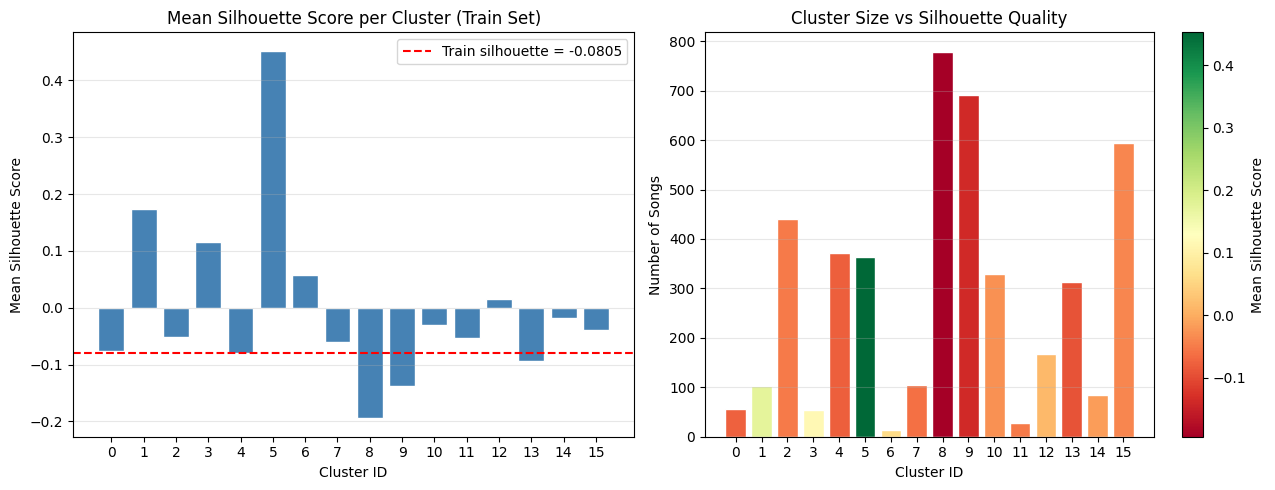


SILHOUETTE INTERPRETATION
  Train silhouette score      : -0.0805
  Validation silhouette score : -0.0800
  Test silhouette score       : -0.1308

  Highest mean silhouette: Cluster 5  (0.4523)
  Lowest  mean silhouette: Cluster 8  (-0.1946)

  Generalisation: The 0.0504 gap between train and test silhouette scores suggests some degree of over-fitting to the training distribution; consider regularising with a simpler covariance type.


In [15]:
# ---------------------------------------------------------------
# SECTION 4 — SILHOUETTE SCORE EVALUATION
# ---------------------------------------------------------------
from sklearn.metrics import silhouette_score, silhouette_samples

# ── Per-split silhouette scores ─────────────────────────────────
labels_all   = songs_gmm['gmm_cluster'].to_numpy()

sil_train = silhouette_score(X[train_idx], labels_all[train_idx])
sil_val   = silhouette_score(X[val_idx],   labels_all[val_idx])
sil_test  = silhouette_score(X[test_idx],  labels_all[test_idx])

print(f"{'Split':<12} {'Silhouette Score':>18}")
print('-' * 31)
print(f"{'Train':<12} {sil_train:>18.4f}")
print(f"{'Validation':<12} {sil_val:>18.4f}")
print(f"{'Test':<12} {sil_test:>18.4f}")

# ── Per-song silhouette values on the full dataset ─────────────
sil_samples = silhouette_samples(X, labels_all)
songs_gmm['silhouette_score'] = sil_samples

# ── Per-cluster stats ───────────────────────────────────────────
cluster_ids = sorted(songs_gmm['gmm_cluster'].unique())
cluster_means = [
    songs_gmm.loc[songs_gmm['gmm_cluster'] == k, 'silhouette_score'].mean()
    for k in cluster_ids
]
cluster_sizes = [
    (songs_gmm['gmm_cluster'] == k).sum()
    for k in cluster_ids
]

# ── Colour map: green=high silhouette, red=low ──────────────────
cmap   = plt.cm.RdYlGn
min_s, max_s = min(cluster_means), max(cluster_means)
norm   = lambda v: (v - min_s) / (max_s - min_s + 1e-9)
colors = [cmap(norm(v)) for v in cluster_means]

# ── Plots ────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: mean silhouette per cluster
ax1.bar(cluster_ids, cluster_means, color='steelblue', edgecolor='white')
ax1.axhline(sil_train, color='red', linestyle='--', linewidth=1.5,
            label=f'Train silhouette = {sil_train:.4f}')
ax1.set_xlabel('Cluster ID')
ax1.set_ylabel('Mean Silhouette Score')
ax1.set_title('Mean Silhouette Score per Cluster (Train Set)')
ax1.set_xticks(cluster_ids)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Right: cluster size coloured by mean silhouette quality
bars = ax2.bar(cluster_ids, cluster_sizes, color=colors, edgecolor='white')
ax2.set_xlabel('Cluster ID')
ax2.set_ylabel('Number of Songs')
ax2.set_title('Cluster Size vs Silhouette Quality')
ax2.set_xticks(cluster_ids)
ax2.grid(axis='y', alpha=0.3)

# Colour bar legend (green=high, red=low silhouette)
sm = plt.cm.ScalarMappable(cmap=cmap,
                            norm=plt.Normalize(vmin=min_s, vmax=max_s))
sm.set_array([])
fig.colorbar(sm, ax=ax2, label='Mean Silhouette Score')

plt.tight_layout()
plt.show()

# ── Interpretation block ─────────────────────────────────────────
best_cluster  = cluster_ids[cluster_means.index(max(cluster_means))]
worst_cluster = cluster_ids[cluster_means.index(min(cluster_means))]

print()
print('=' * 60)
print('SILHOUETTE INTERPRETATION')
print('=' * 60)
print(f'  Train silhouette score      : {sil_train:.4f}')
print(f'  Validation silhouette score : {sil_val:.4f}')
print(f'  Test silhouette score       : {sil_test:.4f}')
print()
print(f'  Highest mean silhouette: Cluster {best_cluster}  '
      f'({max(cluster_means):.4f})')
print(f'  Lowest  mean silhouette: Cluster {worst_cluster}  '
      f'({min(cluster_means):.4f})')
print()
gap = abs(sil_train - sil_test)
if gap < 0.02:
    gen_note = ("Train and test silhouette scores are within 0.02 of each other, "
                "suggesting the model generalises well to unseen popular songs.")
else:
    gen_note = (f"The {gap:.4f} gap between train and test silhouette scores "
                "suggests some degree of over-fitting to the training distribution; "
                "consider regularising with a simpler covariance type.")
print(f'  Generalisation: {gen_note}')
print('=' * 60)

In [16]:
# ---------------------------------------------------------------
# GMM RECOMMENDATION FUNCTION
# ---------------------------------------------------------------
# SMALL_ARTIST_THRESHOLD is defined in the setup cell (Cell 2)


def recommend_small_artists_gmm(input_song, input_artist=None, n_recs=3,
                                  gmm_weight=0.5, cos_weight=0.5):
    """
    Recommend songs from smaller/underground artists that are musically
    similar to a given popular input song.

    How it uses the GMM properly:
      GMM is fit on 9 continuous audio features only (feature_cols =
      base_features). One-hot genre/time_signature columns are excluded
      from GMM training — their binary values force hard cluster assignments
      regardless of reg_covar. The one-hot columns are used for cosine similarity.

      GMM similarity = cosine similarity between posterior probability
      vectors (soft when GMM is trained on continuous features only):

          GMM_sim(seed, candidate) = cos(P(·|seed), P(·|candidate))

      Cosine similarity is computed on the full feature set:
          base_features + onehot_cols  (audio + genre + time_signature)

      Both similarities are blended with the supplied weights.

    Parameters
    ----------
    input_song   : str   — track name of the seed (popular) song
    input_artist : str   — (optional) artist name to disambiguate
    n_recs       : int   — number of recommendations to return (default 3)
    gmm_weight   : float — weight applied to GMM posterior similarity (default 0.5)
    cos_weight   : float — weight applied to cosine feature similarity (default 0.5)
                           gmm_weight + cos_weight need not equal 1, but typically do.

    Returns
    -------
    seed : pd.Series       — the matched seed song row
    recs : pd.DataFrame    — top-n recommended songs
    """

    # 1. Find the seed song ----------------------------------------
    mask = songs_gmm['track_name'].str.lower() == input_song.lower()
    matches = songs_gmm[mask].copy()

    if input_artist:
        am = matches['track_artist'].str.lower().str.contains(
            input_artist.lower(), na=False
        )
        if am.any():
            matches = matches[am]

    # Fallback: partial name match
    if matches.empty:
        mask = songs_gmm['track_name'].str.lower().str.contains(
            input_song.lower(), na=False
        )
        matches = songs_gmm[mask].copy()

    if matches.empty:
        raise ValueError(f"Song '{input_song}' not found in dataset.")

    # Use the most popular match as the seed
    seed = matches.sort_values('track_popularity', ascending=False).iloc[0]

    # Cosine similarity uses full feature set (audio + one-hot genre/time_sig)
    full_feature_cols = base_features + onehot_cols
    seed_vec   = seed[full_feature_cols].to_numpy(dtype=float).reshape(1, -1)
    seed_probs = seed[prob_cols].to_numpy(dtype=float)   # (n_components,)

    # 2. Candidate pool: small artists only, exclude seed ----------
    candidates = songs_gmm[
        (songs_gmm['artist_top_track_popularity'] < SMALL_ARTIST_THRESHOLD) &
        (songs_gmm['track_id'] != seed['track_id'])
    ].copy()

    if candidates.empty:
        raise ValueError(
            f"No small-artist songs found (threshold={SMALL_ARTIST_THRESHOLD})."
        )

    # 3. Score candidates ------------------------------------------
    # (a) GMM similarity: cosine similarity between posterior probability
    #     vectors. Soft posteriors are achieved by training GMM on
    #     continuous features only (one-hot exclusion, not reg_covar).
    from sklearn.metrics.pairwise import cosine_similarity as cos_sim_fn
    cand_probs = candidates[prob_cols].to_numpy(dtype=float)     # (n, n_components)
    gmm_sim    = cos_sim_fn(seed_probs.reshape(1, -1),           # (n,)
                            cand_probs).flatten()

    # (b) Cosine similarity in full feature space (audio + one-hot cols)
    cand_feats  = candidates[full_feature_cols].to_numpy(dtype=float)
    cos_sim     = cosine_similarity(seed_vec, cand_feats).flatten()

    # (c) Combined score — weighted blend of GMM and cosine similarity
    candidates['gmm_similarity'] = gmm_sim
    candidates['cos_similarity'] = cos_sim
    candidates['score']          = gmm_weight * gmm_sim + cos_weight * cos_sim

    # 4. Return top n_recs -----------------------------------------
    recs = (
        candidates
        .sort_values('score', ascending=False)
        .head(n_recs)
        [['track_name', 'track_artist', 'track_popularity',
          'artist_top_track_popularity', 'gmm_cluster',
          'gmm_similarity', 'cos_similarity', 'score']]
        .reset_index(drop=True)
    )

    return seed, recs


# ---------------------------------------------------------------
# DEMO  — change input_song to any track in the dataset
# ---------------------------------------------------------------
input_song   = "Taste"
input_artist = None          # set e.g. "Tate McRae" to disambiguate

seed, recs = recommend_small_artists_gmm(
    input_song, input_artist=input_artist, n_recs=3
)

print("=" * 62)
print("INPUT SONG")
print(f"  Title  : {seed['track_name']}")
print(f"  Artist : {seed['track_artist']}")
print(f"  Track popularity          : {seed['track_popularity']:.2f}")
print(f"  Artist top-track pop.     : {seed['artist_top_track_popularity']:.2f}")
print(f"  GMM cluster               : {seed['gmm_cluster']}")
print("=" * 62)
print(f"\nTOP {len(recs)} RECOMMENDATIONS FROM SMALLER ARTISTS\n")

for i, row in recs.iterrows():
    print(f"  {i+1}. \"{row['track_name']}\"  by  {row['track_artist']}")
    print(f"     Artist top-track popularity : {row['artist_top_track_popularity']:.2f}")
    print(f"     GMM sim : {row['gmm_similarity']:.4f}  |  "
          f"Cosine sim : {row['cos_similarity']:.4f}  |  "
          f"Score : {row['score']:.4f}")
    print()

INPUT SONG
  Title  : Taste
  Artist : Sabrina Carpenter
  Track popularity          : 0.92
  Artist top-track pop.     : 0.93
  GMM cluster               : 8

TOP 3 RECOMMENDATIONS FROM SMALLER ARTISTS

  1. "Lovesick (feat. Liza Owen)"  by  SJUR, Liza Owen
     Artist top-track popularity : 0.21
     GMM sim : 0.9630  |  Cosine sim : 0.9950  |  Score : 0.9790

  2. "Sorry"  by  Emma Steinbakken
     Artist top-track popularity : 0.22
     GMM sim : 0.9658  |  Cosine sim : 0.9919  |  Score : 0.9789

  3. "Välkommen Åter"  by  Hanna Ferm, Junie
     Artist top-track popularity : 0.47
     GMM sim : 0.9608  |  Cosine sim : 0.9851  |  Score : 0.9729

